## IMPORTING NECESSARY LIBRARIES

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings =
import warnings
warnings.filterwarnings("ignore")

## LOADING DATA

In [2]:
try:
    df = pd.read_csv('../data/diabetes.csv')
except FileNotFoundError:
    print("File not found")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Dataset Feature Description

| Column Name                | What It Means                                                                 | Example Values / Notes                       |
|---------------------------|--------------------------------------------------------------------------------|---------------------------------------------|
| `Pregnancies`             | How many times the person has been pregnant                                   | 0, 1, 2, ...                                  |
| `Glucose`                 | Blood sugar level measured after a test                                       | 80, 120, 150, etc.                            |
| `BloodPressure`           | Blood pressure value (the lower number)                                       | 70, 80, 90, etc.                              |
| `SkinThickness`           | Thickness of skin on the back of the arm (used to estimate body fat)          | 20, 35, 0 (0 means missing)                   |
| `Insulin`                 | Insulin level in the blood                                                    | 85, 130, 0 (0 means missing)                  |
| `BMI`                     | Body Mass Index (a number showing weight vs height)                           | 25.3, 30.1, 0 (0 means missing or unknown)    |
| `DiabetesPedigreeFunction`| A number showing how likely diabetes is based on family history               | 0.3, 1.0, 2.2, etc.                           |
| `Age`                     | Age of the person                                                             | 21, 35, 50, etc.                              |
| `Outcome`                 | Whether the person has diabetes (1) or not (0)                                | 0 = No diabetes, 1 = Has diabetes             |


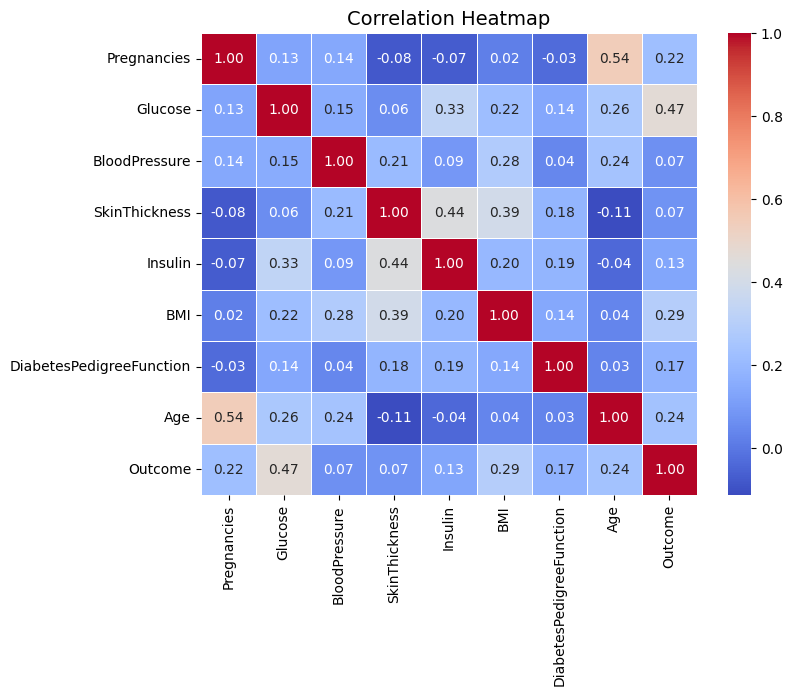

In [6]:
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

Text(0.5, 1.0, 'Age Distribution')

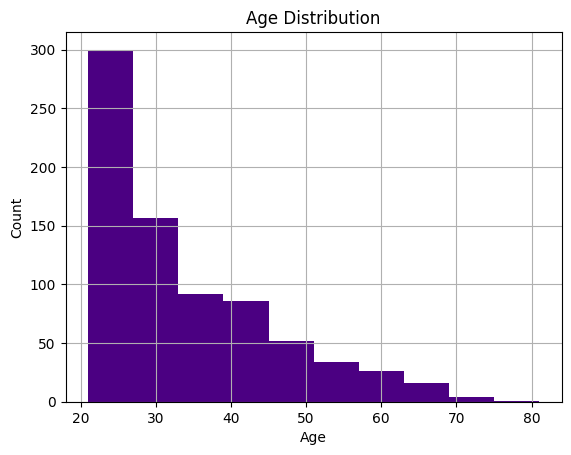

In [7]:
df["Age"].hist(color = "indigo")
plt.xlabel('Age')  
plt.ylabel('Count')  
plt.title('Age Distribution') 

In [8]:
df['BloodPressure'].unique()

array([ 72,  66,  64,  40,  74,  50,   0,  70,  96,  92,  80,  60,  84,
        30,  88,  90,  94,  76,  82,  75,  58,  78,  68, 110,  56,  62,
        85,  86,  48,  44,  65, 108,  55, 122,  54,  52,  98, 104,  95,
        46, 102, 100,  61,  24,  38, 106, 114])

In [9]:
def categorize_diastolic(bp):
    if bp < 60:
        return 'Low'
    elif 60 <= bp < 80:
        return 'Normal'
    elif 80 <= bp < 90:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

df['BloodPressureCategory'] = df['BloodPressure'].apply(categorize_diastolic)

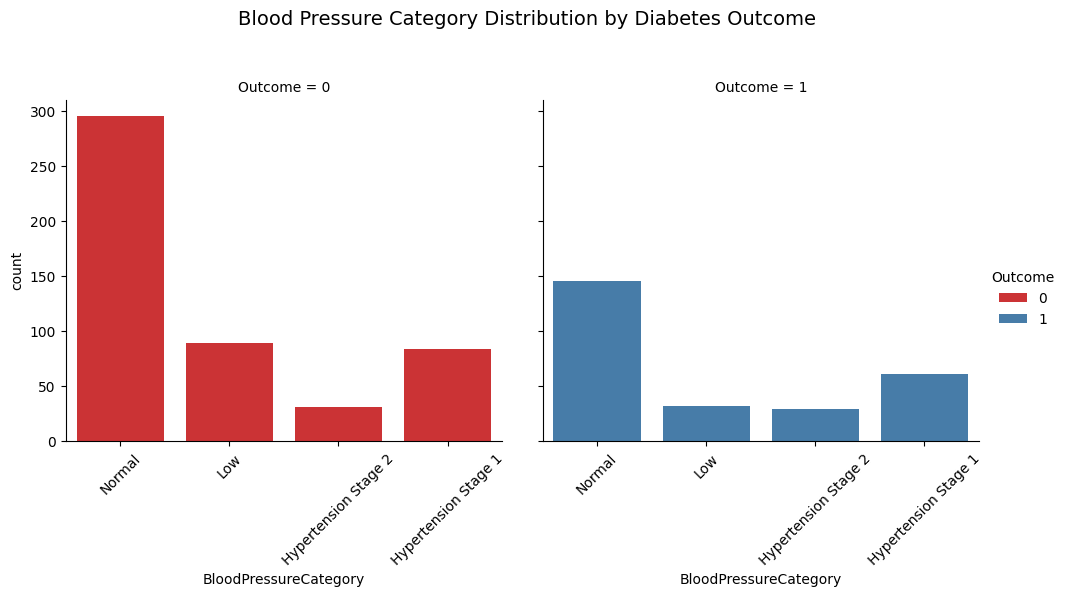

In [10]:
g = sns.catplot(
    data=df,
    kind='count',
    x='BloodPressureCategory',
    hue='Outcome',
    col='Outcome',
    palette='Set1',
    height=5,
    aspect=1
)

# Rotate x-tick labels on each subplot
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.subplots_adjust(top=0.8)
plt.suptitle("Blood Pressure Category Distribution by Diabetes Outcome", fontsize=14)
plt.show()

In [11]:
df['Glucose'].unique()

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126,  99, 196, 119, 143, 147,  97,
       145, 117, 109, 158,  88,  92, 122, 138, 102,  90, 111, 180, 133,
       106, 171, 159, 146,  71, 105, 101, 176, 150,  73, 187,  84,  44,
       141, 114,  95, 129,  79,   0,  62, 131, 112, 113,  74,  83, 136,
        80, 123,  81, 134, 142, 144,  93, 163, 151,  96, 155,  76, 160,
       124, 162, 132, 120, 173, 170, 128, 108, 154,  57, 156, 153, 188,
       152, 104,  87,  75, 179, 130, 194, 181, 135, 184, 140, 177, 164,
        91, 165,  86, 193, 191, 161, 167,  77, 182, 157, 178,  61,  98,
       127,  82,  72, 172,  94, 175, 195,  68, 186, 198, 121,  67, 174,
       199,  56, 169, 149,  65, 190])

In [12]:
def classify_glucose(g):
    if g < 70:
        return 'Low'
    elif 70 <= g < 100:
        return 'Normal'
    elif 100 <= g < 126:
        return 'Prediabetes'
    else:
        return 'Diabetes'

df['GlucoseCategory'] = df['Glucose'].apply(classify_glucose)

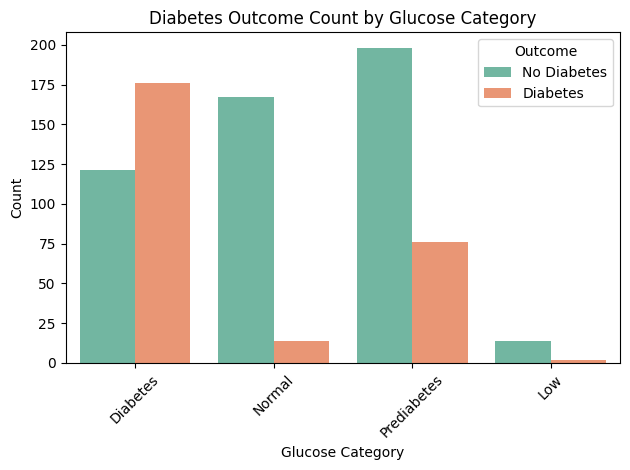

In [13]:
sns.countplot(data=df, x='GlucoseCategory', hue='Outcome', palette='Set2')
plt.title('Diabetes Outcome Count by Glucose Category')
plt.xticks(rotation=45)
plt.xlabel('Glucose Category')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.show()


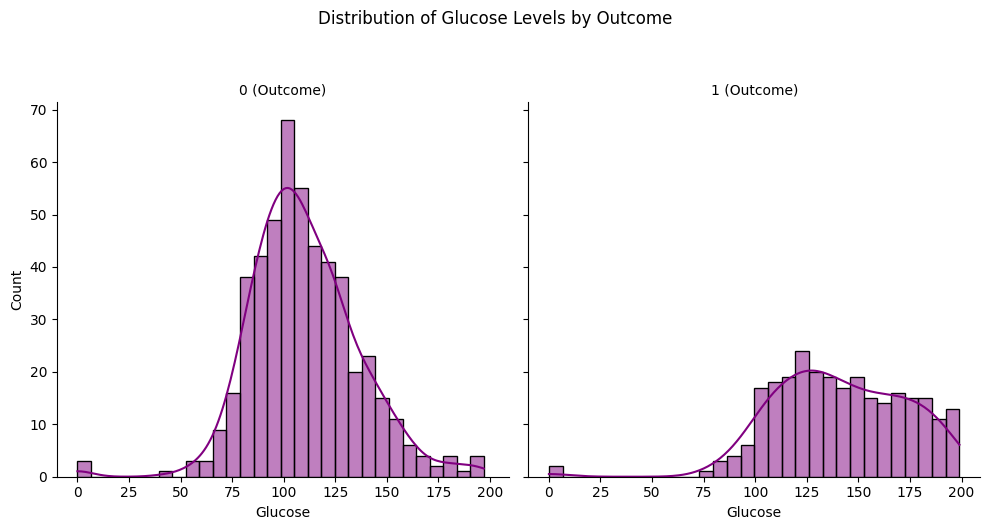

In [14]:
g = sns.FacetGrid(df, col='Outcome', height=5, aspect=1)
g.map(sns.histplot, 'Glucose', bins=30, kde=True, color='purple')
g.set_titles(col_template="{col_name} (Outcome)")
g.set_axis_labels("Glucose", "Count")
plt.suptitle("Distribution of Glucose Levels by Outcome", y=1.05)
plt.tight_layout()
plt.show()

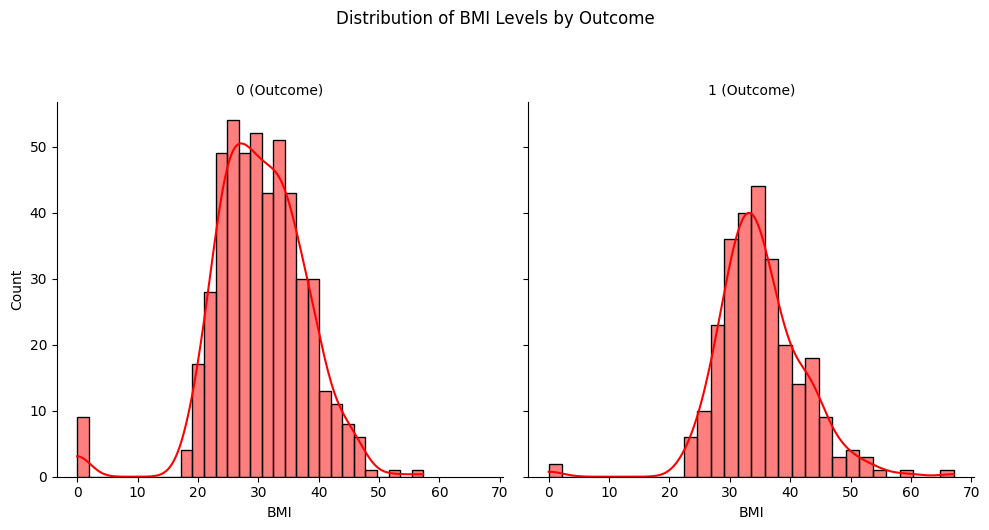

In [15]:
g = sns.FacetGrid(df, col='Outcome', height=5, aspect=1)
g.map(sns.histplot, 'BMI', bins=30, kde=True, color='red')
g.set_titles(col_template="{col_name} (Outcome)")
g.set_axis_labels("BMI", "Count")
plt.suptitle("Distribution of BMI Levels by Outcome", y=1.05)
plt.tight_layout()
plt.show()

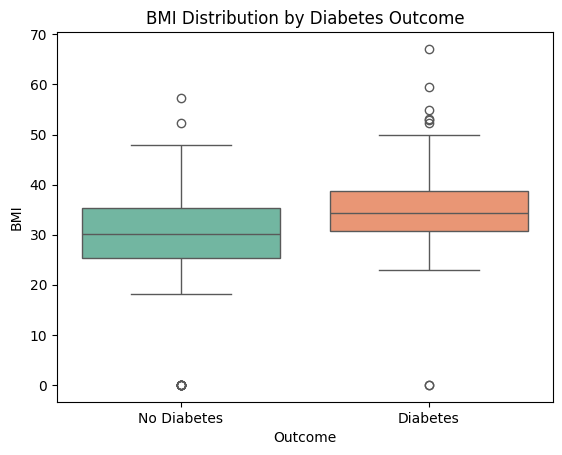

In [16]:
sns.boxplot(data=df, x='Outcome', y='BMI', palette='Set2')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('BMI')
plt.show()

In [17]:
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMICategory'] = df['BMI'].apply(classify_bmi)

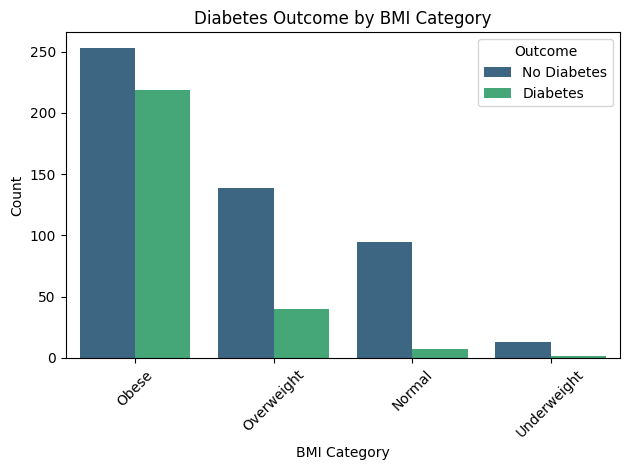

In [18]:
sns.countplot(data=df, x='BMICategory', hue='Outcome', palette='viridis')
plt.title('Diabetes Outcome by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Outcome', labels=['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.show()

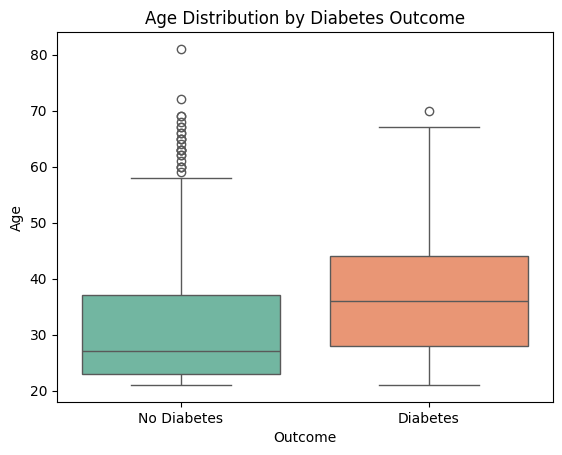

In [19]:
sns.boxplot(data=df, x='Outcome', y='Age', palette='Set2')
plt.title('Age Distribution by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Age')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

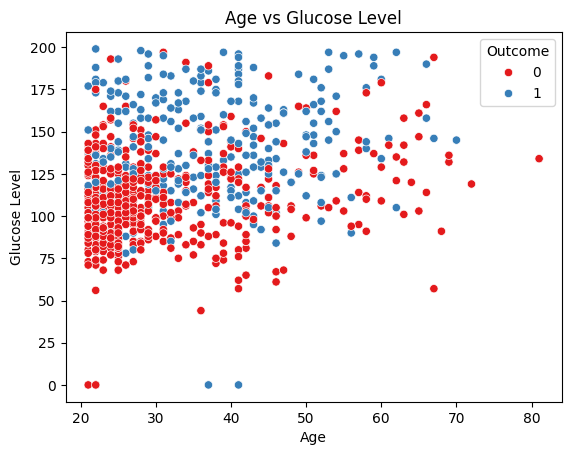

In [20]:
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', palette='Set1')
plt.title('Age vs Glucose Level')
plt.xlabel('Age')
plt.ylabel('Glucose Level')
plt.show()

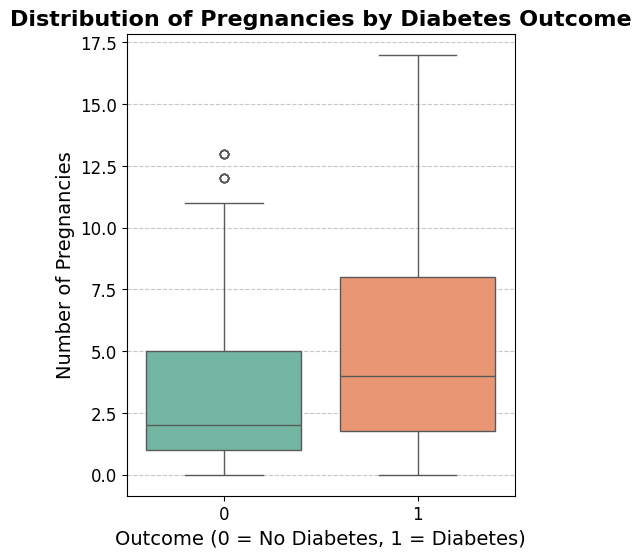

In [21]:
plt.figure(figsize=(5, 6))
sns.boxplot(x='Outcome', y='Pregnancies', data=df, palette='Set2')

plt.title('Distribution of Pregnancies by Diabetes Outcome', fontsize=16, fontweight='bold')
plt.suptitle('')  
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)', fontsize=14)
plt.ylabel('Number of Pregnancies', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

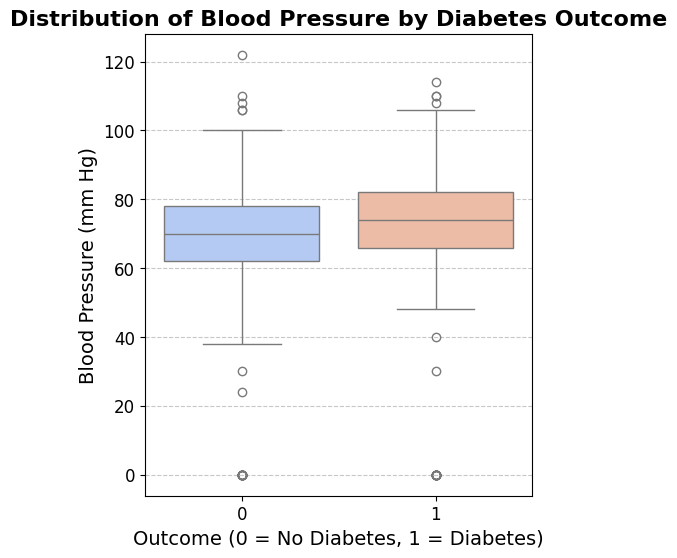

In [22]:
plt.figure(figsize=(5, 6))
sns.boxplot(x='Outcome', y='BloodPressure', data=df, palette='coolwarm')

plt.title('Distribution of Blood Pressure by Diabetes Outcome', fontsize=16, fontweight='bold')
plt.suptitle('')  
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)', fontsize=14)
plt.ylabel('Blood Pressure (mm Hg)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Finding Outliers

In [23]:
num_df = df.select_dtypes(include=['number'])

outlier_percentages = {}

for feature in num_df.columns:
    Q1 = num_df[feature].quantile(0.25)
    Q3 = num_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = num_df[(num_df[feature] < lower) | (num_df[feature] > upper)]
    
    # Calculate outlier percentage
    outlier_percentage = (len(outliers) / len(num_df)) * 100
    outlier_percentages[feature] = round(outlier_percentage, 2)

outlier_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['Outlier Percentage (%)'])
outlier_df = outlier_df.sort_values(by='Outlier Percentage (%)', ascending=False)

outlier_df

,Outlier Percentage (%)
BloodPressure,5.86
Insulin,4.43
DiabetesPedigreeFunction,3.78
BMI,2.47
Age,1.17
Glucose,0.65
Pregnancies,0.52
SkinThickness,0.13
Outcome,0.00


In [24]:
from scipy.stats import mstats

# Winsorizing specific features
features_to_winsorize = ['BloodPressure', 'Insulin', 'DiabetesPedigreeFunction']

for feature in features_to_winsorize:
    # Apply Winsorization for the identified features
    df[feature] = mstats.winsorize(df[feature], limits=[0.05, 0.05])  # Limits of 5% for both lower and upper
    
    print(f"After Winsorizing {feature}:")
    print(df[feature].describe())  # Show summary stats for comparison
    print("-" * 50)  # Separator for readability

# Check the first few rows after Winsorization to see changes
print(df.head())

After Winsorizing BloodPressure:
count    768.000000
mean      70.403646
std       13.012824
min       38.000000
25%       62.000000
50%       72.000000
75%       80.000000
max       90.000000
Name: BloodPressure, dtype: float64
--------------------------------------------------
After Winsorizing Insulin:
count    768.000000
mean      72.462240
std       90.568989
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      293.000000
Name: Insulin, dtype: float64
--------------------------------------------------
After Winsorizing DiabetesPedigreeFunction:
count    768.000000
mean       0.457349
std        0.277178
min        0.140000
25%        0.243750
50%        0.372500
75%        0.626250
max        1.136000
Name: DiabetesPedigreeFunction, dtype: float64
--------------------------------------------------
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1     

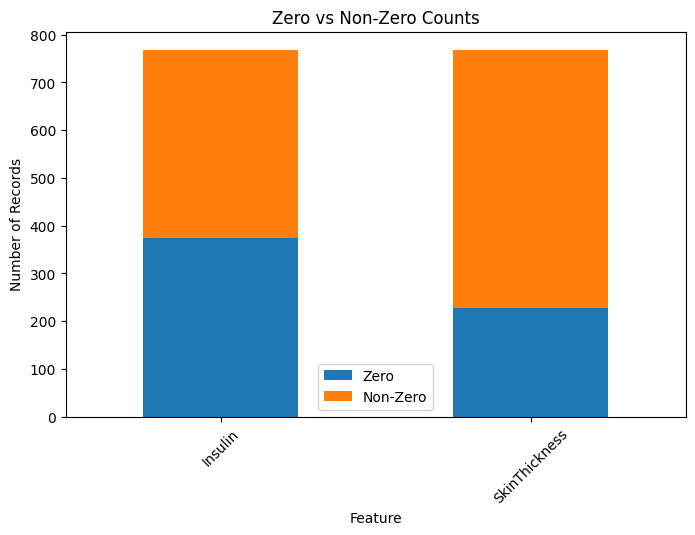

In [33]:
zero_counts = {
    'Insulin': (df['Insulin'] == 0).sum(),
    'SkinThickness': (df['SkinThickness'] == 0).sum()
}
non_zero_counts = {
    'Insulin': (df['Insulin'] != 0).sum(),
    'SkinThickness': (df['SkinThickness'] != 0).sum()
}

# Convert to DataFrame for plotting
zero_df = pd.DataFrame({
    'Feature': ['Insulin', 'SkinThickness'],
    'Zero': [zero_counts['Insulin'], zero_counts['SkinThickness']],
    'Non-Zero': [non_zero_counts['Insulin'], non_zero_counts['SkinThickness']]
}).set_index('Feature')

zero_df.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Zero vs Non-Zero Counts')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()


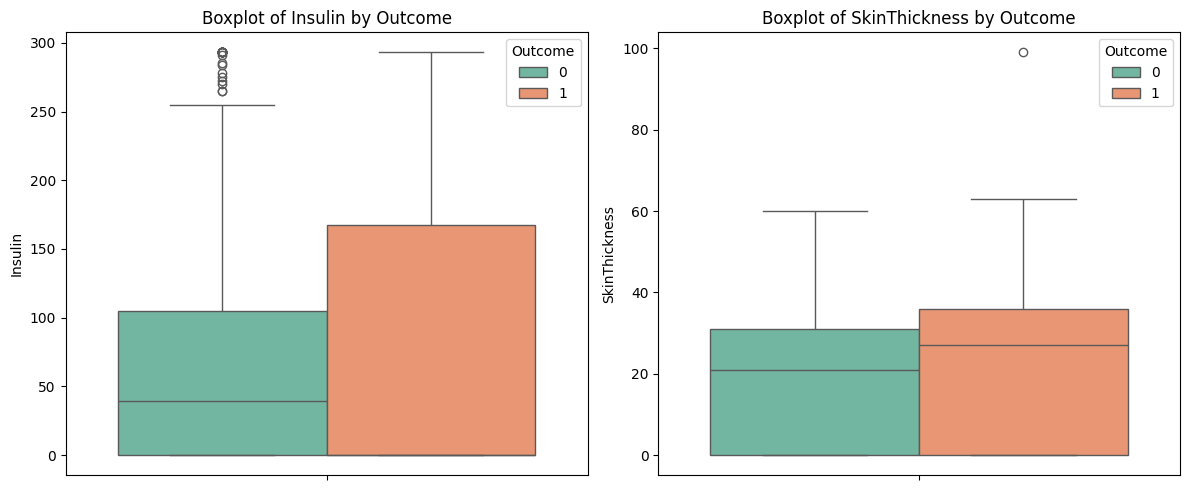

In [32]:
plt.figure(figsize=(12, 5))

# Choose a clean color palette
palette = sns.color_palette('Set2')

plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='Insulin', hue='Outcome', palette=palette)
plt.title('Boxplot of Insulin by Outcome')
plt.ylabel('Insulin')
plt.xlabel('')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='SkinThickness', hue='Outcome', palette=palette)
plt.title('Boxplot of SkinThickness by Outcome')
plt.ylabel('SkinThickness')
plt.xlabel('')

plt.tight_layout()
plt.show()